## Confirmatory data analysis

- ordinal logistic regression `cgpa ~ stress_z_score + anxiety_z_score + depression_z_score`
- ordinal logistic regression with control variables `+ department + academic_year + gender`
- separate adjusted ordinal logistic models (one condition at a time)
- pca-based latent distress model
- practical significance
    - multicollinearity diagnostic (VIF)
    - one-way ANOVA by condition level (`stress_level`, `anxiety_level`, `depression_level`)
    - chi-square independence test `severity x cgpa` (`stress_level`, `anxiety_level`, `depression_level`)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from scipy.stats import f_oneway, chi2_contingency

from pathlib import Path

### global constants

In [3]:
# assume notebook is run from proj_root/mhp/
ROOT = Path.cwd().parent
DATA = ROOT / "mhp" / "data"
PLOTS = ROOT / "mhp" / "plots"

OUTCOME_COL = "cgpa"
Z_SCORE_COLS = ["stress_z_score", "anxiety_z_score", "depression_z_score"]
SEVERITY_COLS = ["stress_level", "anxiety_level", "depression_level"]
CONTROL_COLS = ["department", "academic_year", "gender"]

CLEAN_LABELS = {
    "stress_z_score": "Stress",
    "anxiety_z_score": "Anxiety",
    "depression_z_score": "Depression",
    "department_eng_mech": "Mech. Engineering",
    "department_business": "Business",
    "department_eng_civil": "Civil Engineering",
    "department_eng_cs": "Computer Science",
    "department_eng_eee": "Electrical Engineering",
    "department_env_life_sciences": "Env. & Life Sciences",
    "department_other": "Other Department",
    "department_not_recorded": "Dept. Not Recorded",
    "academic_year_second": "2nd Year",
    "academic_year_third": "3rd Year",
    "academic_year_fourth": "4th Year",
    "academic_year_other": "Other Year",
    "academic_year_unknown": "Year Not Recorded",
    "gender_male": "Male",
    "gender_other": "Other Gender",
    "mh_distress_pc1": "Global Distress",
}

sns.set_theme(
    style="whitegrid", rc={"axes.spines.right": False, "axes.spines.top": False}
)
# color scheme
COLOR_PRIMARY = "steelblue"
COLOR_NEGATIVE = "indianred"
COLOR_POSITIVE = "mediumseagreen"
COLOR_NEUTRAL = "darkgray"
CMAP = "Blues"

In [4]:
mhp_dataset = pd.read_parquet(DATA / "mhp_dataset.parquet")

# clean dataset and drop sparse departments
df_clean = (
    mhp_dataset[[OUTCOME_COL] + Z_SCORE_COLS + CONTROL_COLS + SEVERITY_COLS]
    .dropna()
    .copy()
)
sparse_depts = ["eng_other", "pharmacy", "law", "liberal_arts"]
df_clean = (
    df_clean[~df_clean["department"].isin(sparse_depts)]
    .copy()
    .reset_index(drop=True)
)

y = df_clean[OUTCOME_COL].cat.codes
X_num = df_clean[Z_SCORE_COLS].astype(float)
X_cat = pd.get_dummies(
    df_clean[CONTROL_COLS].astype(str), drop_first=True, dtype=float
)
X_full = X_num.join(X_cat)

### plotting helper

In [5]:
def plot_forest(
    result_df: pd.DataFrame, title: str, figsize: tuple[int, int] = (8, 6)
) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    for i, row in enumerate(result_df.itertuples()):
        is_sig = row.p_value < 0.05
        if is_sig and row.odds_ratio < 1:
            color = COLOR_NEGATIVE
        elif is_sig and row.odds_ratio > 1:
            color = COLOR_POSITIVE
        else:
            color = COLOR_NEUTRAL

        font_weight = "bold" if is_sig else "normal"

        ax.errorbar(
            x=row.odds_ratio,
            y=i,
            xerr=[
                [row.odds_ratio - row.ci_low],
                [row.ci_high - row.odds_ratio],
            ],
            fmt="o",
            color=color,
            capsize=5,
            linewidth=2,
            markersize=8,
            zorder=3,
        )

        label_name = CLEAN_LABELS.get(
            row.term, row.term.replace("_", " ").title()
        )
        label_text = f"{label_name} (OR={row.odds_ratio:.2f})"
        ax.annotate(
            label_text,
            (row.odds_ratio, i),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            va="bottom",
            color=color,
            fontweight=font_weight,
        )

    ax.axvline(1.0, linestyle="--", color="black", alpha=0.6, zorder=2)

    ax.set_ylim(-0.5, len(result_df) + 0.5)
    ax.set_yticks([])
    ax.set_xlabel(
        "Odds Ratio (multiplicative effect on likelihood of higher grades)"
    )
    ax.set_title(title, fontweight="bold", pad=25)
    ax.set_xlim(
        result_df["ci_low"].min() - 0.1, result_df["ci_high"].max() + 0.1
    )

    transform = blended_transform_factory(ax.transData, ax.transAxes)
    xmin, xmax = ax.get_xlim()
    span = xmax - xmin

    ax.axvspan(xmin, 1, color=COLOR_NEGATIVE, alpha=0.15, zorder=0)
    ax.axvspan(1, xmax, color=COLOR_POSITIVE, alpha=0.15, zorder=0)

    ax.text(
        xmin + 0.15 * span,
        1.02,
        "← Worsens CGPA",
        transform=transform,
        ha="center",
        va="bottom",
        color=COLOR_NEGATIVE,
        fontweight="bold",
    )
    ax.text(
        xmax - 0.15 * span,
        1.02,
        "Improves CGPA →",
        transform=transform,
        ha="center",
        va="bottom",
        color=COLOR_POSITIVE,
        fontweight="bold",
    )

    return fig, ax

### unadjusted ordinal regression

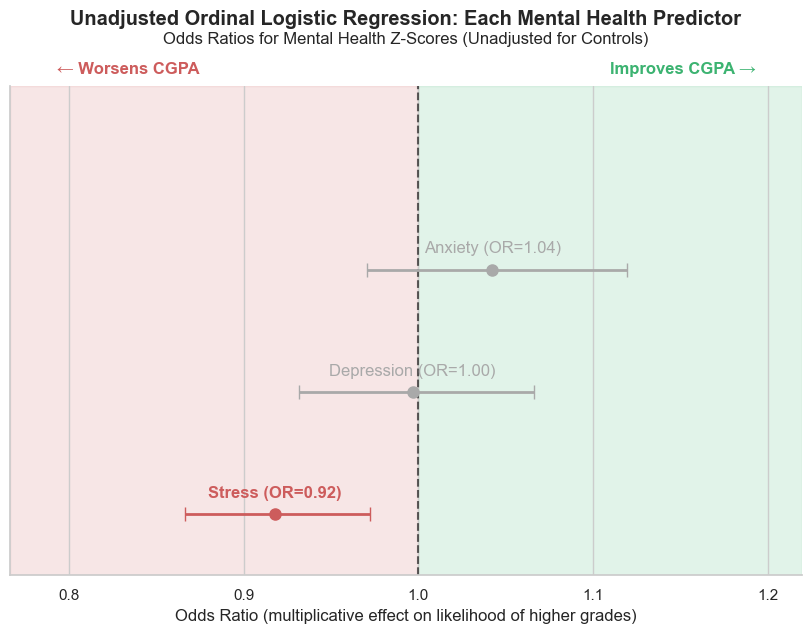

In [6]:
model_unadjusted = OrderedModel(y, X_num, dists="logit")
result_unadjusted = model_unadjusted.fit(method="bfgs", disp=False)

conf_unadjusted = result_unadjusted.conf_int()
results_unadjusted = (
    pd.DataFrame(
        {
            "term": Z_SCORE_COLS,
            "odds_ratio": np.exp(result_unadjusted.params[Z_SCORE_COLS]),
            "ci_low": np.exp(conf_unadjusted.loc[Z_SCORE_COLS, 0]),
            "ci_high": np.exp(conf_unadjusted.loc[Z_SCORE_COLS, 1]),
            "p_value": result_unadjusted.pvalues[Z_SCORE_COLS],
        }
    )
    .sort_values("odds_ratio")
    .reset_index(drop=True)
)

fig, ax = plot_forest(results_unadjusted, "")
fig.suptitle(
    "Unadjusted Ordinal Logistic Regression: Each Mental Health Predictor",
    fontweight="bold",
    y=1.03,
)
ax.set_title(
    "Odds Ratios for Mental Health Z-Scores (Unadjusted for Controls)", y=1.07
)
plt.show()

In [7]:
fig.savefig(
    PLOTS / "unadjusted_ordinal_logistic_regression.svg",
    format="svg",
    bbox_inches="tight",
)

### adjusted ordinal regression

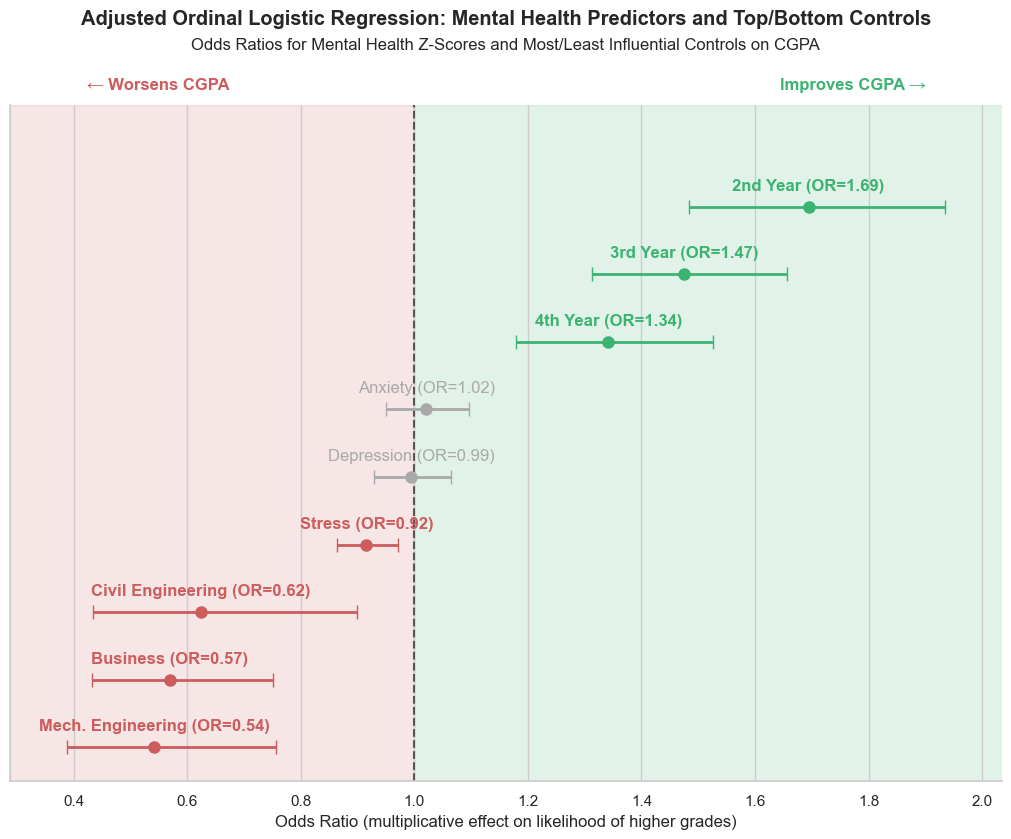

In [9]:
model_adjusted = OrderedModel(y, X_full, dists="logit")
result_adjusted = model_adjusted.fit(method="bfgs", disp=False)

features_adjusted = X_full.columns.tolist()
conf_adjusted = result_adjusted.conf_int()
results_adjusted = (
    pd.DataFrame(
        {
            "term": features_adjusted,
            "odds_ratio": np.exp(result_adjusted.params[features_adjusted]),
            "ci_low": np.exp(conf_adjusted.loc[features_adjusted, 0]),
            "ci_high": np.exp(conf_adjusted.loc[features_adjusted, 1]),
            "p_value": result_adjusted.pvalues[features_adjusted],
        }
    )
    .sort_values("odds_ratio")
    .reset_index(drop=True)
)

# select mental health predictor rows
# and the three lowest/highest control variables by odds ratio
plot_df = (
    pd.concat(
        [
            results_adjusted[results_adjusted["term"].isin(Z_SCORE_COLS)],
            results_adjusted[
                ~results_adjusted["term"].isin(Z_SCORE_COLS)
            ].nsmallest(3, "odds_ratio"),
            results_adjusted[
                ~results_adjusted["term"].isin(Z_SCORE_COLS)
            ].nlargest(3, "odds_ratio"),
        ]
    )
    .drop_duplicates(subset=["term"])
    .sort_values("odds_ratio")
)

fig, ax = plot_forest(plot_df, "", figsize=(10, 8))
fig.suptitle(
    "Adjusted Ordinal Logistic Regression: Mental Health Predictors and Top/Bottom Controls",
    fontweight="bold",
    y=1.03,
)
ax.set_title(
    "Odds Ratios for Mental Health Z-Scores and Most/Least Influential Controls on CGPA",
    y=1.07,
)

plt.show()

In [196]:
fig.savefig(
    PLOTS / "adjusted_ordinal_logistic_regression.svg",
    format="svg",
    bbox_inches="tight",
)

### separate adjusted ordinal logistic regressions (one condition at a time)

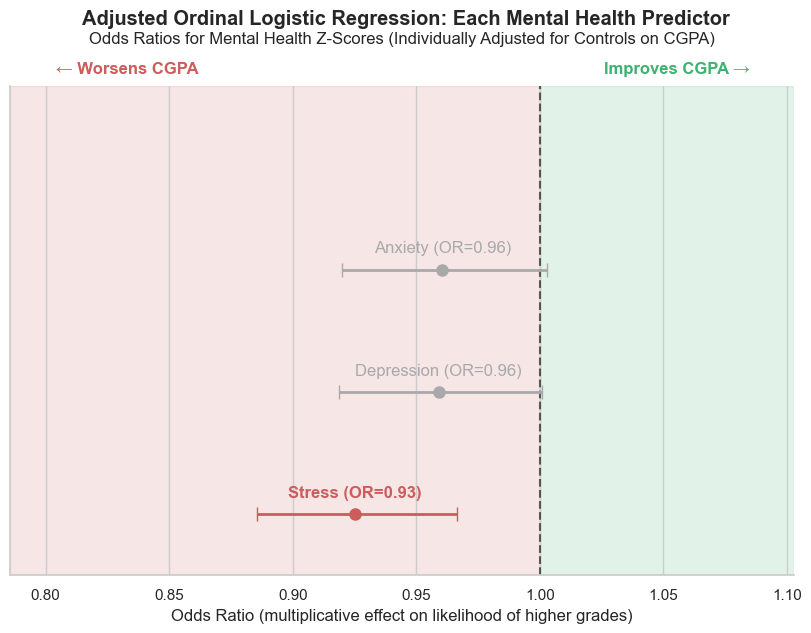

In [197]:
isolated_results = []

for z_score in Z_SCORE_COLS:
    X_isolated = df_clean[[z_score]].astype(float).join(X_cat)

    model_isolated = OrderedModel(y, X_isolated, dists="logit")
    result_isolated = model_isolated.fit(method="bfgs", disp=False)

    isolated_results.append(
        {
            "term": z_score,
            "odds_ratio": np.exp(result_isolated.params[z_score]),
            "ci_low": np.exp(result_isolated.conf_int().loc[z_score, 0]),
            "ci_high": np.exp(result_isolated.conf_int().loc[z_score, 1]),
            "p_value": result_isolated.pvalues[z_score],
        }
    )

isolated_results_df = (
    pd.DataFrame(isolated_results)
    .sort_values("odds_ratio")
    .reset_index(drop=True)
)

fig, ax = plot_forest(isolated_results_df, "")
fig.suptitle(
    "Adjusted Ordinal Logistic Regression: Each Mental Health Predictor",
    fontweight="bold",
    y=1.03,
)
ax.set_title(
    "Odds Ratios for Mental Health Z-Scores (Individually Adjusted for Controls on CGPA)",
    y=1.07,
)
plt.show()

In [198]:
fig.savefig(
    PLOTS / "isolated_adjusted_ordinal_logistic_regression.svg",
    format="svg",
    bbox_inches="tight",
)

### pca-based latent distress model

PC1 (Global Distress) captures 79.1% of mental health variance


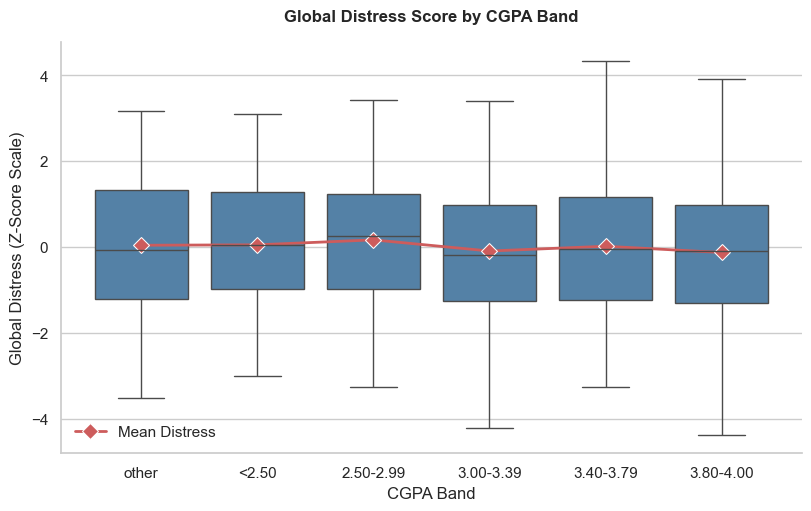

In [ ]:
pca = PCA(n_components=1)
pc1 = pca.fit_transform(X_num).ravel()

if np.corrcoef(pc1, df_clean["stress_z_score"])[0, 1] < 0:
    pc1 = pc1 * -1

df_clean["mh_distress_pc1"] = pc1
mh_variance = pca.explained_variance_ratio_[0] * 100
print(
    f"PC1 (Global Distress) captures {mh_variance:.1f}% of mental health variance"
)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
means = (
    df_clean.groupby(OUTCOME_COL, observed=True)["mh_distress_pc1"]
    .mean()
    .reset_index()
)

sns.boxplot(
    data=df_clean,
    x=OUTCOME_COL,
    y="mh_distress_pc1",
    color=COLOR_PRIMARY,
    ax=ax,
    showfliers=False,
)
sns.lineplot(
    data=means,
    x=OUTCOME_COL,
    y="mh_distress_pc1",
    color=COLOR_NEGATIVE,
    marker="D",
    markersize=8,
    linewidth=2,
    label="Mean Distress",
    ax=ax,
)

ax.set_title("Global Distress Score by CGPA Band", fontweight="bold", pad=15)
ax.set_xlabel("CGPA Band")
ax.set_ylabel("Global Distress (Z-Score Scale)")
ax.legend(frameon=False, loc="lower left")

plt.show()

In [200]:
fig.savefig(
    PLOTS / "global_distress_by_cgpa_band.svg",
    format="svg",
    bbox_inches="tight",
)

### practical significance

- multicollinearity diagnostic (VIF)
- one-way ANOVA by condition level (`stress_level`, `anxiety_level`, `depression_level`)
- chi-square independence test `severity x cgpa` (`stress_level`, `anxiety_level`, `depression_level`)

,Condition,VIF Score
0,Stress,1.89
1,Anxiety,2.90
2,Depression,2.59


,Metric,F-Statistic,P-Value,Eta-Squared
0,Stress Level,4.62,0.00034,0.0097
1,Anxiety Level,1.57,0.1656,0.0033
2,Depression Level,2.15,0.05702,0.0045


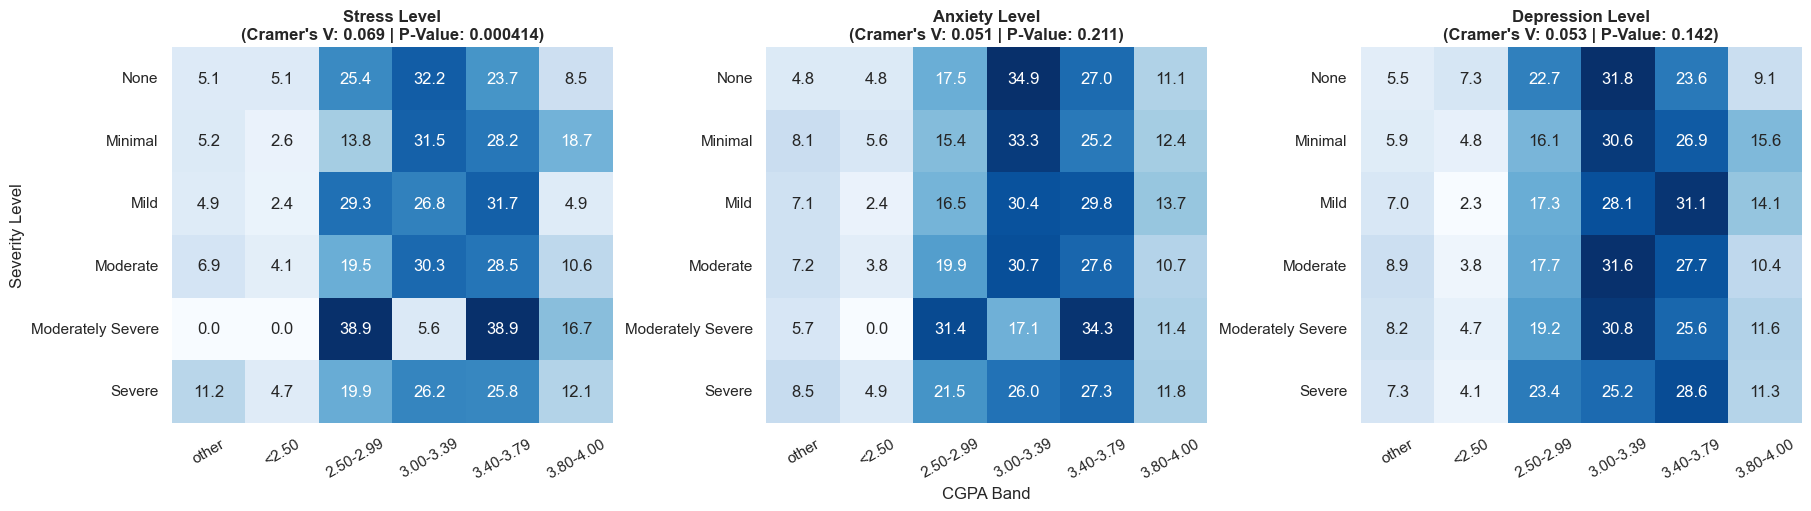

In [ ]:
# multicollinearity (VIF)
vif_data = pd.DataFrame(
    {
        "Condition": [CLEAN_LABELS[z_score] for z_score in Z_SCORE_COLS],
        "VIF Score": [
            variance_inflation_factor(X_num.values, i)
            for i in range(X_num.shape[1])
        ],
    }
)
display(vif_data.style.format({"VIF Score": "{:.2f}"}))


# one-way ANOVA and eta-squared effect size
df_clean["cgpa_code"] = df_clean[OUTCOME_COL].cat.codes.astype(float)
anova_results = []

for sev in SEVERITY_COLS:
    groups = [
        group["cgpa_code"].values
        for _, group in df_clean.groupby(sev, observed=True)
    ]
    f_stat, p_val = f_oneway(*groups)

    k, N = len(groups), len(df_clean)
    eta_sq = (f_stat * (k - 1)) / ((f_stat * (k - 1)) + (N - k))

    anova_results.append(
        {
            "Metric": CLEAN_LABELS.get(sev, sev.replace("_", " ").title()),
            "F-Statistic": f_stat,
            "P-Value": p_val,
            "Eta-Squared": eta_sq,
        }
    )

anova_df = pd.DataFrame(anova_results)
display(
    anova_df.style.format(
        {"F-Statistic": "{:.2f}", "P-Value": "{:.4g}", "Eta-Squared": "{:.4f}"}
    ).map(lambda x: "font-weight: bold" if x < 0.05 else "", subset=["P-Value"])
)


# chi-square heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, sev_col in zip(axes, SEVERITY_COLS):
    ct = pd.crosstab(df_clean[sev_col], df_clean[OUTCOME_COL])
    chi2, p_val, dof, _ = chi2_contingency(ct)

    cramers_v = np.sqrt(chi2 / (ct.to_numpy().sum() * (min(ct.shape) - 1)))
    prop = ct.div(ct.sum(axis=1), axis=0) * 100

    sns.heatmap(prop, annot=True, fmt=".1f", cmap=CMAP, cbar=False, ax=ax)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
    ax.set_yticklabels([str(lbl).replace("_", " ").title() for lbl in ct.index])
    ax.set_title(
        (
            f"{sev_col.replace('_', ' ').title()}\n"
            f"(Cramer's V: {cramers_v:.3f} | P-Value: {p_val:.3g})"
        ),
        fontweight="bold",
    )
    ax.set_xlabel("CGPA Band" if ax == axes[1] else "")
    ax.set_ylabel("Severity Level" if ax == axes[0] else "")

plt.show()

In [202]:
fig.savefig(
    PLOTS / "chi_square_heatmaps.svg", format="svg", bbox_inches="tight"
)